In [55]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_20newsgroups
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB , BernoulliNB
from sklearn.metrics import(accuracy_score,precision_score,recall_score,f1_score ,roc_curve,confusion_matrix)
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

In [56]:
train_data = fetch_20newsgroups( subset="train",remove=("headers","footers","quotes"))

In [57]:
test_data =  fetch_20newsgroups( subset="test",remove=("headers","footers","quotes"))

In [58]:
X_train_text = train_data.data
y_train =train_data.target

X_test_text = test_data.data
y_test = test_data.target

class_names = train_data.target_names

In [59]:
print("Training documents :",len(X_train_text))
print("Testing documents  :",len(X_test_text)) 
print("Number of classes  :",len(class_names))

Training documents : 11314
Testing documents  : 7532
Number of classes  : 20


In [60]:
vectorizer = CountVectorizer(stop_words="english",min_df=2)
X_train = vectorizer.fit_transform(X_train_text)
X_test = vectorizer.transform(X_test_text)

In [61]:
print("Training feature matrix:",X_train.shape)
print("Testing feature matrix:",X_test.shape)

Training feature matrix: (11314, 39115)
Testing feature matrix: (7532, 39115)


In [62]:
mnb = MultinomialNB()
mnb.fit(X_train,y_train)
y_pred_mnb = mnb.predict(X_test)

In [63]:
binary_vectorizer = CountVectorizer(stop_words ="english",min_df=2,binary=True)
X_train_binary = binary_vectorizer.fit_transform(X_train_text)
X_test_binary=binary_vectorizer.transform(X_test_text)

In [64]:
bnb = BernoulliNB()
bnb.fit (X_train_binary,y_train)
y_pred_bnb =bnb.predict(X_test_binary)

In [65]:
mnb_accuracy = accuracy_score(y_test, y_pred_mnb)

mnb_precision = precision_score(
y_test,
y_pred_mnb,
average='weighted'
)

mnb_recall = recall_score(
y_test,
y_pred_mnb,
average='weighted'
)

mnb_f1 = f1_score(
y_test,
y_pred_mnb,
average='weighted'
)

print("Multinomial Naive Bayes")
print("Accuracy :", mnb_accuracy)
print("Precision:", mnb_precision)
print("Recall :", mnb_recall)
print("F1-Score :", mnb_f1)

Multinomial Naive Bayes
Accuracy : 0.6510886882634095
Precision: 0.642532222238185
Recall : 0.6510886882634095
F1-Score : 0.6296441343359875


In [66]:
bnb_accuracy = accuracy_score(y_test, y_pred_bnb)

bnb_precision = precision_score(
y_test,
y_pred_bnb,
average='weighted'
)

bnb_recall = recall_score(
y_test,
y_pred_bnb,
average='weighted'
)

bnb_f1 = f1_score(
y_test,
y_pred_bnb,
average='weighted'
)

print("Bernoulli Naive Bayes")
print("Accuracy :", bnb_accuracy)
print("Precision:", bnb_precision)
print("Recall :", bnb_recall)
print("F1-Score :", bnb_f1)

Bernoulli Naive Bayes
Accuracy : 0.4851301115241636
Precision: 0.6270343160004399
Recall : 0.4851301115241636
F1-Score : 0.4808387927958853


In [67]:
results = pd.DataFrame({
'Model': [
'Multinomial NB',
'Bernoulli NB'
],
'Accuracy': [
mnb_accuracy,
bnb_accuracy
],
'Precision': [
mnb_precision,
bnb_precision
],
'Recall': [
mnb_recall,
bnb_recall
],
'F1-Score': [
mnb_f1,
bnb_f1
]
})

results

,Model,Accuracy,Precision,Recall,F1-Score
0,Multinomial NB,0.651089,0.642532,0.651089,0.629644
1,Bernoulli NB,0.485130,0.627034,0.485130,0.480839


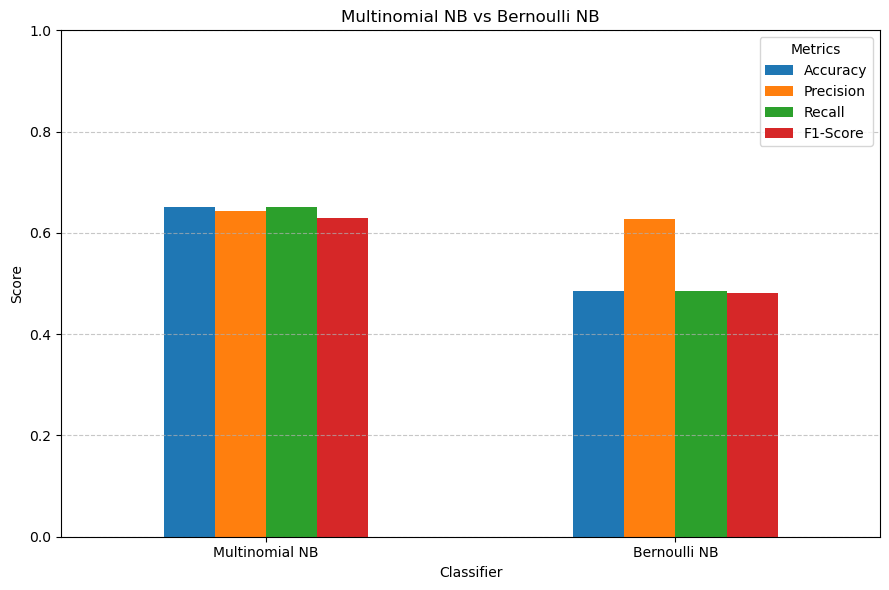

In [68]:
results.set_index('Model').plot(
kind='bar',
figsize=(9, 6)
)

plt.title('Multinomial NB vs Bernoulli NB')
plt.xlabel('Classifier')
plt.ylabel('Score')
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(title='Metrics')
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

In [69]:

y_test_bin = label_binarize(
y_test,
classes=mnb.classes_
)

mnb_prob = mnb.predict_proba(X_test)
bnb_prob = bnb.predict_proba(X_test_binary)

In [71]:
fpr_mnb, tpr_mnb, _ = roc_curve(
y_test_bin.ravel(),
mnb_prob.ravel()
)

fpr_bnb, tpr_bnb, _ = roc_curve(
y_test_bin.ravel(),
bnb_prob.ravel()
)

mnb_auc = auc(fpr_mnb, tpr_mnb)
bnb_auc = auc(fpr_bnb, tpr_bnb)

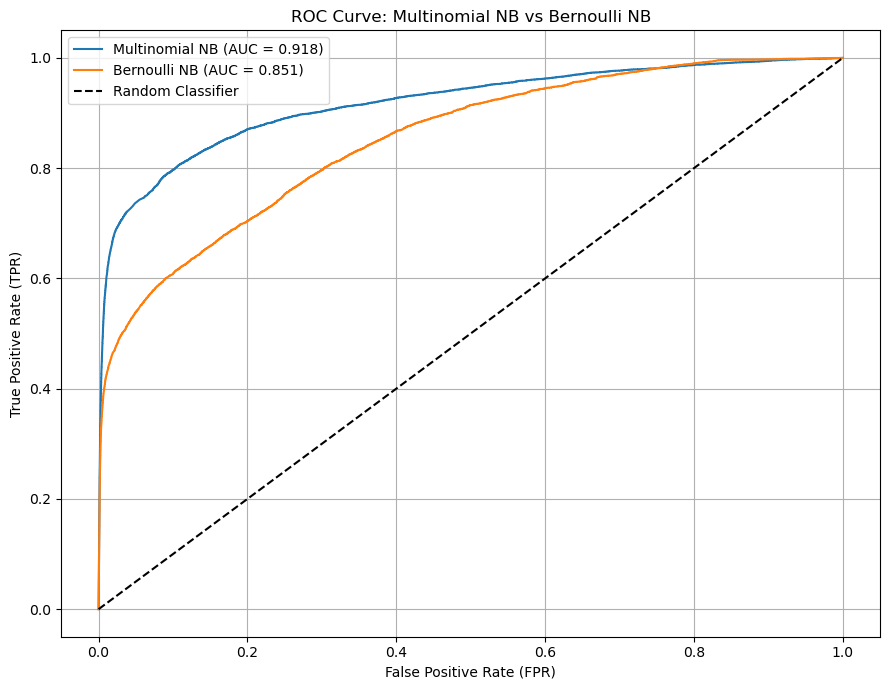

In [72]:
plt.figure(figsize=(9, 7))

plt.plot(
fpr_mnb,
tpr_mnb,
label=f'Multinomial NB (AUC = {mnb_auc:.3f})'
)

plt.plot(
fpr_bnb,
tpr_bnb,
label=f'Bernoulli NB (AUC = {bnb_auc:.3f})'
)

plt.plot(
[0, 1],
[0, 1],
'k--',
label='Random Classifier'
)

plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('ROC Curve: Multinomial NB vs Bernoulli NB')

plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()